In [5]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [6]:
df = pd.read_csv('../data/email_spam_detection.csv')
data = df.copy()

In [7]:
df.shape

(7000, 9)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6999 non-null   str    
 2   Subject            7000 non-null   str    
 3   Email_Length       6959 non-null   float64
 4   Num_Links          7000 non-null   int64  
 5   Num_Special_Chars  7000 non-null   int64  
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 694.4 KB


In [9]:
df.isnull().sum()

Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
df.nunique()


Email_ID             7000
Sender_Email         6973
Subject                 8
Email_Length          233
Num_Links              15
Num_Special_Chars      30
Capital_Words          60
Has_Attachment          2
Spam                    2
dtype: int64

Spam
0    4864
1    2136
Name: count, dtype: int64
Spam
0    0.695
1    0.305
Name: proportion, dtype: float64


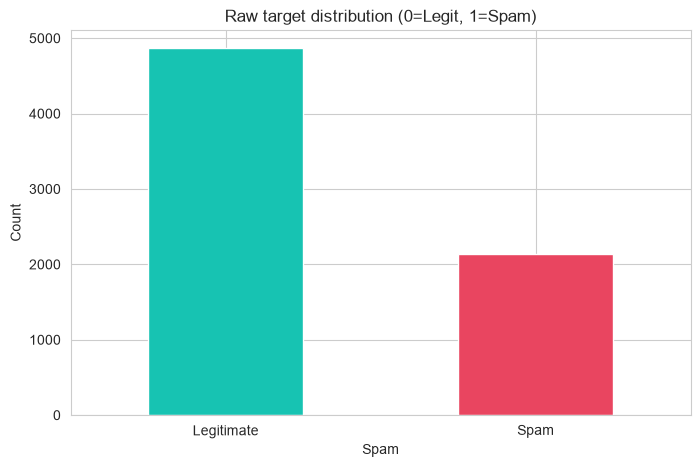

In [12]:
print(df["Spam"].value_counts())
print(df["Spam"].value_counts(normalize=True).round(3))

df["Spam"].value_counts().plot(
    kind="bar", color=["#17c3b2", "#e94560"], title="Raw target distribution (0=Legit, 1=Spam)"
)
plt.xticks([0, 1], ["Legitimate", "Spam"], rotation=0)
plt.ylabel("Count")
plt.show()


In [13]:
df["Sender_Email"] = df["Sender_Email"].astype(str).str.strip()
df.loc[df["Sender_Email"].isin(["", "nan", "None"]), "Sender_Email"] = np.nan
print("Blank/NaN sender emails found:", df["Sender_Email"].isna().sum())
df["Sender_Email"] = df["Sender_Email"].fillna("unknown@unknown.com")

Blank/NaN sender emails found: 28


In [14]:
n_special_sentinel = (df["Num_Special_Chars"] == -1).sum()
n_links_sentinel = (df["Num_Links"] == 99).sum()
print(f"Num_Special_Chars == -1 (sentinel): {n_special_sentinel} rows")
print(f"Num_Links == 99 (sentinel): {n_links_sentinel} rows")

Num_Special_Chars == -1 (sentinel): 23 rows
Num_Links == 99 (sentinel): 17 rows


In [15]:
df.loc[df["Num_Special_Chars"] == -1, "Num_Special_Chars"] = np.nan
df.loc[df["Num_Links"] == 99, "Num_Links"] = np.nan

In [16]:
print("\nMissing values before imputation:")
print(df[["Email_Length", "Num_Links", "Num_Special_Chars"]].isnull().sum())



Missing values before imputation:
Email_Length         41
Num_Links            17
Num_Special_Chars    23
dtype: int64


In [17]:
for col in ["Email_Length", "Num_Special_Chars", "Num_Links"]:
    df[col] = df.groupby("Spam")[col].transform(lambda s: s.fillna(s.median()))

df["Email_Length"] = df["Email_Length"].astype(float)
df["Num_Links"] = df["Num_Links"].astype(float)
df["Num_Special_Chars"] = df["Num_Special_Chars"].astype(float)
df["Has_Attachment"] = df["Has_Attachment"].astype(int)
df["Spam"] = df["Spam"].astype(int)

print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Email_ID             0
Sender_Email         0
Subject              0
Email_Length         0
Num_Links            0
Num_Special_Chars    0
Capital_Words        0
Has_Attachment       0
Spam                 0
dtype: int64


In [18]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows. New shape: {df.shape}")

Removed 0 duplicate rows. New shape: (7000, 9)


In [19]:
def iqr_outliers(frame, col):
    q1, q3 = frame[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((frame[col] < low) | (frame[col] > high)).sum(), (low, high)

for col in ["Email_Length", "Num_Links", "Num_Special_Chars", "Capital_Words"]:
    n_out, bounds = iqr_outliers(df, col)
    print(f"{col}: {n_out} IQR outliers (bounds {bounds[0]:.1f} to {bounds[1]:.1f})")


Email_Length: 0 IQR outliers (bounds -62.0 to 290.0)
Num_Links: 283 IQR outliers (bounds -4.5 to 7.5)
Num_Special_Chars: 26 IQR outliers (bounds -11.5 to 24.5)
Capital_Words: 1349 IQR outliers (bounds -7.9 to 21.1)


In [20]:
df["email_domain_preview"] = df["Sender_Email"].str.split("@").str[-1]
print(sorted(df["email_domain_preview"].unique())[:10])
df = df.drop(columns=["email_domain_preview"])

print(df.dtypes)

['company.com', 'gmail.com', 'outlook.com', 'unknown.com', 'yahoo.com']
Email_ID               int64
Sender_Email             str
Subject                  str
Email_Length         float64
Num_Links            float64
Num_Special_Chars    float64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object


In [21]:
df["Spam"].value_counts(normalize=True).round(3)

Spam
0    0.695
1    0.305
Name: proportion, dtype: float64

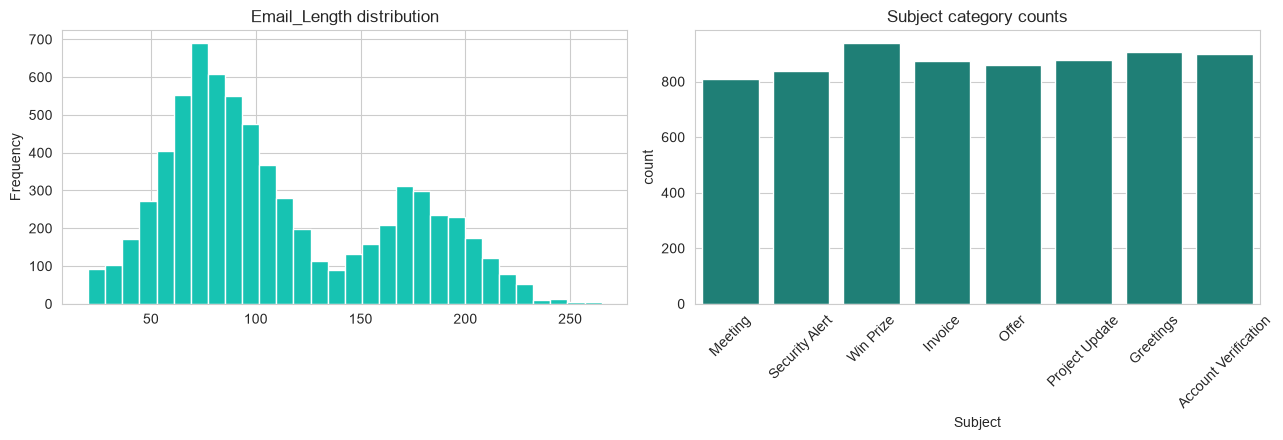

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df["Email_Length"].plot(kind="hist", bins=30, ax=axes[0], color="#17c3b2")
axes[0].set_title("Email_Length distribution")
sns.countplot(x="Subject", data=df, ax=axes[1], color="#0f8f83")
axes[1].set_title("Subject category counts")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

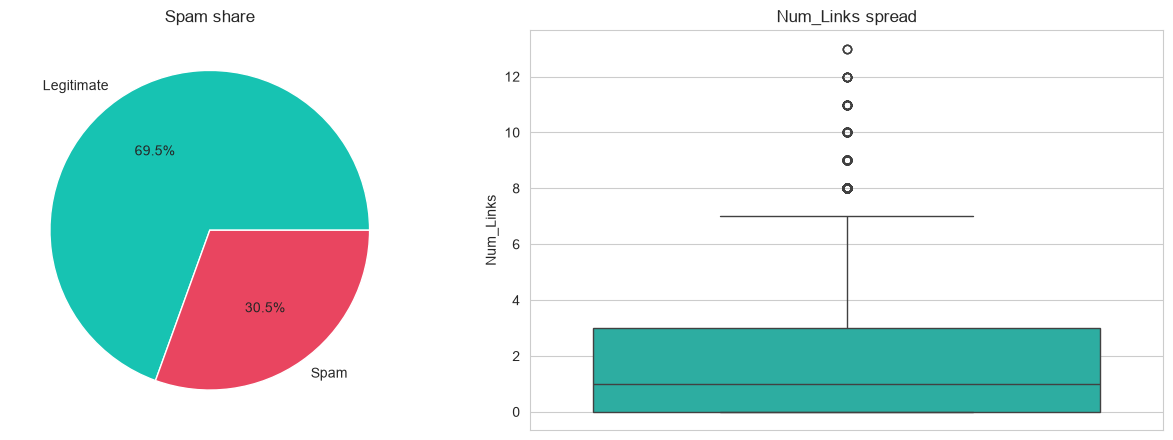

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df["Spam"].value_counts().plot(
    kind="pie", labels=["Legitimate", "Spam"], autopct="%1.1f%%",
    colors=["#17c3b2", "#e94560"], ax=axes[0]
)
axes[0].set_ylabel("")
axes[0].set_title("Spam share")
sns.boxplot(y="Num_Links", data=df, ax=axes[1], color="#17c3b2")
axes[1].set_title("Num_Links spread")
plt.tight_layout()
plt.show()


C:\Users\praja\AppData\Local\Temp\ipykernel_15248\1686717715.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Spam", y="Capital_Words", data=df, ax=axes[2], palette=["#17c3b2", "#e94560"])
C:\Users\praja\AppData\Local\Temp\ipykernel_15248\1686717715.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[2].set_xticklabels(["Legitimate", "Spam"])


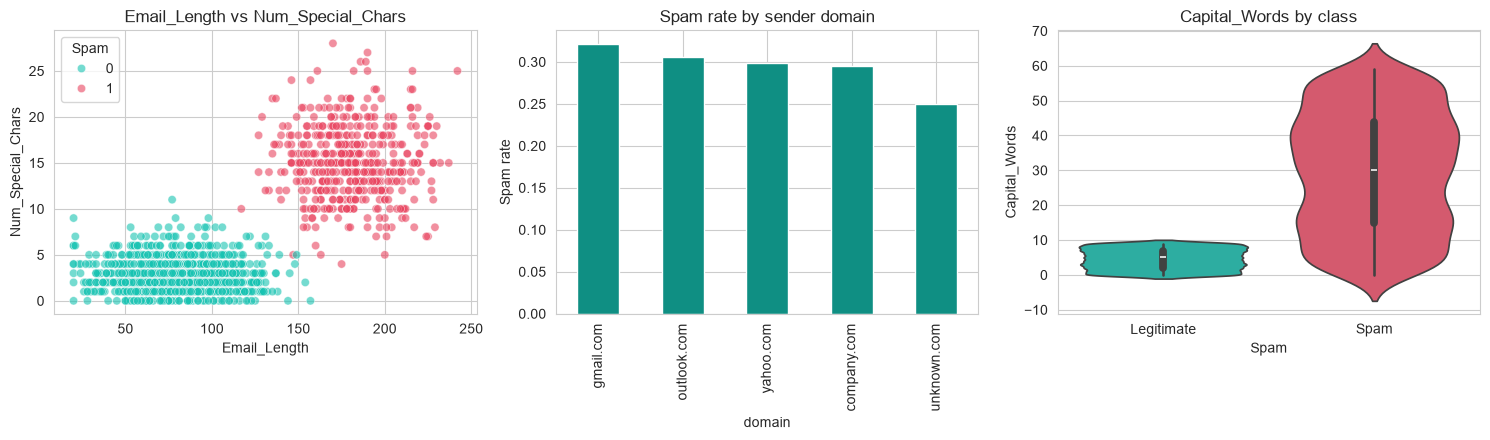

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.scatterplot(
    data=df.sample(1500, random_state=42), x="Email_Length", y="Num_Special_Chars",
    hue="Spam", palette=["#17c3b2", "#e94560"], alpha=0.6, ax=axes[0]
)
axes[0].set_title("Email_Length vs Num_Special_Chars")

domain_spam = (
    df.assign(domain=df["Sender_Email"].str.split("@").str[-1])
    .groupby("domain")["Spam"].mean().sort_values(ascending=False)
)
domain_spam.plot(kind="bar", ax=axes[1], color="#0f8f83")
axes[1].set_title("Spam rate by sender domain")
axes[1].set_ylabel("Spam rate")

sns.violinplot(x="Spam", y="Capital_Words", data=df, ax=axes[2], palette=["#17c3b2", "#e94560"])
axes[2].set_xticklabels(["Legitimate", "Spam"])
axes[2].set_title("Capital_Words by class")
plt.tight_layout()
plt.show()


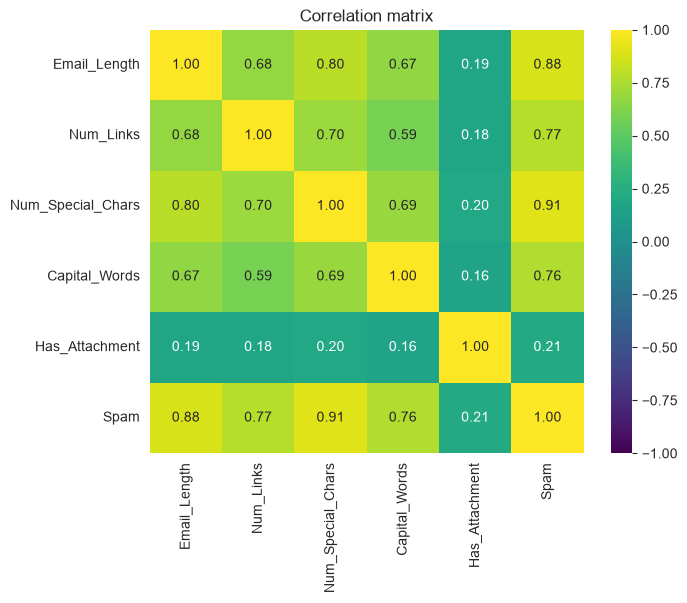

In [25]:
numeric_cols = ["Email_Length", "Num_Links", "Num_Special_Chars", "Capital_Words", "Has_Attachment", "Spam"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

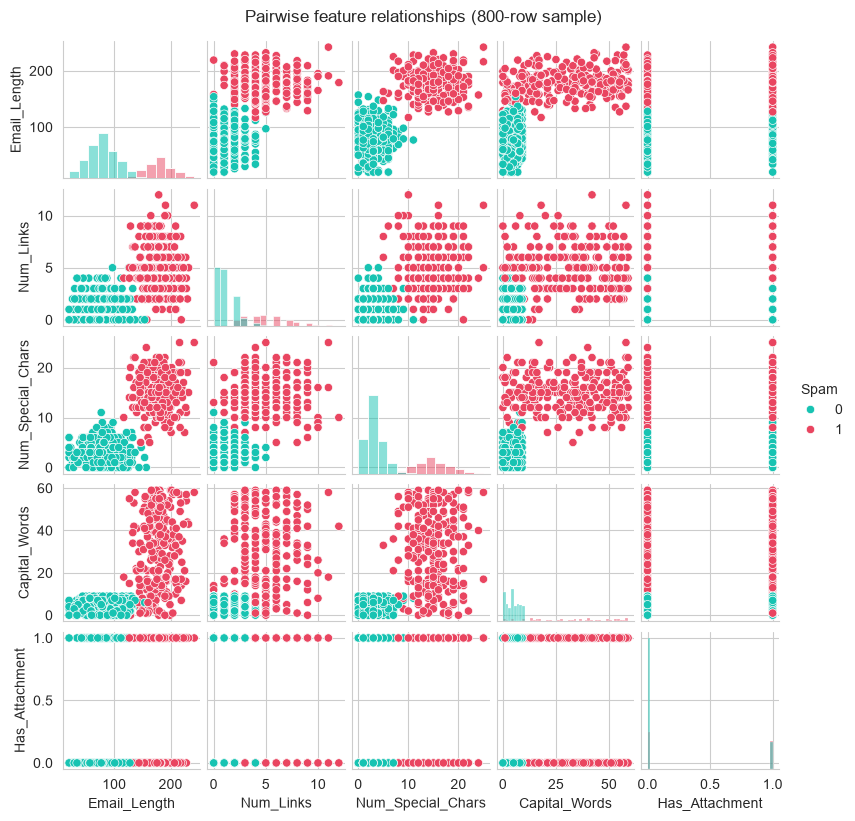

In [26]:
sample = df[numeric_cols].sample(800, random_state=42)
sns.pairplot(sample, hue="Spam", palette=["#17c3b2", "#e94560"], diag_kind="hist", height=1.6)
plt.suptitle("Pairwise feature relationships (800-row sample)", y=1.02)
plt.show()


In [27]:
URGENT_SUBJECTS = {"Security Alert", "Account Verification", "Win Prize"}

def add_engineered_columns(frame):
    frame = frame.copy()
    frame["email_domain"] = frame["Sender_Email"].apply(
        lambda x: x.split("@")[-1] if isinstance(x, str) and "@" in x else "unknown"
    )
    frame["subject_length"] = frame["Subject"].astype(str).str.len()
    frame["is_urgent_subject"] = frame["Subject"].isin(URGENT_SUBJECTS).astype(int)
    return frame

df_feat = add_engineered_columns(df)
df_feat[["Sender_Email", "email_domain", "Subject", "subject_length", "is_urgent_subject"]].head()


,Sender_Email,email_domain,Subject,subject_length,is_urgent_subject
0,unknown@unknown.com,unknown.com,Meeting,7,0
1,user1@outlook.com,outlook.com,Security Alert,14,1
2,user2@yahoo.com,yahoo.com,Win Prize,9,1
3,user3@gmail.com,gmail.com,Invoice,7,0
4,user4@company.com,company.com,Meeting,7,0


In [28]:
CATEGORICAL_FEATURES = ["email_domain", "Subject"]
NUMERIC_FEATURES = [
    "Email_Length", "Num_Links", "Num_Special_Chars", "Capital_Words",
    "Has_Attachment", "subject_length", "is_urgent_subject",
]

X = df_feat[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = df_feat["Spam"]
X.head()


,email_domain,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,subject_length,is_urgent_subject
0,unknown.com,Meeting,79.0,1.0,3.0,7,0,7,0
1,outlook.com,Security Alert,87.0,2.0,3.0,8,0,14,1
2,yahoo.com,Win Prize,69.0,0.0,3.0,8,0,9,1
3,gmail.com,Invoice,61.0,0.0,3.0,8,0,7,0
4,company.com,Meeting,99.0,2.0,3.0,5,0,7,0


In [29]:
CONTINUOUS_TO_SCALE = ["Email_Length", "Num_Links", "Num_Special_Chars", "Capital_Words", "subject_length"]
BINARY_PASSTHROUGH = ["Has_Attachment", "is_urgent_subject"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), CONTINUOUS_TO_SCALE),
    ],
    remainder="passthrough", 
)
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))


Train shape: (5600, 9) | Test shape: (1400, 9)
Train class balance:
 Spam
0    0.695
1    0.305
Name: proportion, dtype: float64


In [31]:
preprocessor_preview = ColumnTransformer(
    transformers=[("num", StandardScaler(), CONTINUOUS_TO_SCALE)], remainder="drop"
)
preprocessor_preview.fit(X_train)
scaled_preview = preprocessor_preview.transform(X_train)
pd.DataFrame(scaled_preview, columns=CONTINUOUS_TO_SCALE).describe().loc[["mean", "std"]].round(2)


,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,subject_length
mean,-0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0


In [32]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42, class_weight="balanced"
    ),
    "Naive Bayes": GaussianNB(),
}
list(candidates.keys())


['Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes']

In [33]:
fitted_pipelines = {}
predictions = {}
probabilities = {}

for name, clf in candidates.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    predictions[name] = pipe.predict(X_test)
    probabilities[name] = pipe.predict_proba(X_test)[:, 1]

print("Trained:", list(fitted_pipelines.keys()))


Trained: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes']


In [34]:
results = {}
for name in candidates:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Spam"]))



--- Logistic Regression ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       973
        Spam       1.00      1.00      1.00       427

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400


--- Decision Tree ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       973
        Spam       1.00      1.00      1.00       427

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400


--- Random Forest ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       973
        Spam       1.00      1.00      1.00       427

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400

In [35]:
results_df = pd.DataFrame(results).T.round(4)
results_df.sort_values("ROC-AUC", ascending=False)


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9993,0.9977,1.0000,0.9988,1.0000
Random Forest,0.9993,0.9977,1.0000,0.9988,1.0000
Naive Bayes,0.9986,0.9953,1.0000,0.9977,1.0000
Decision Tree,0.9979,0.9953,0.9977,0.9965,0.9978


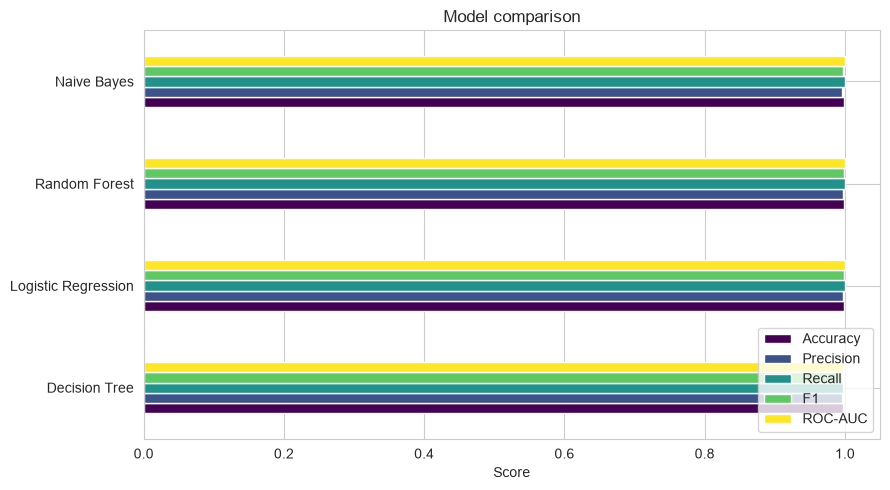

In [36]:
results_df.sort_values("ROC-AUC")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="barh", figsize=(9, 5), colormap="viridis"
)
plt.title("Model comparison")
plt.xlabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


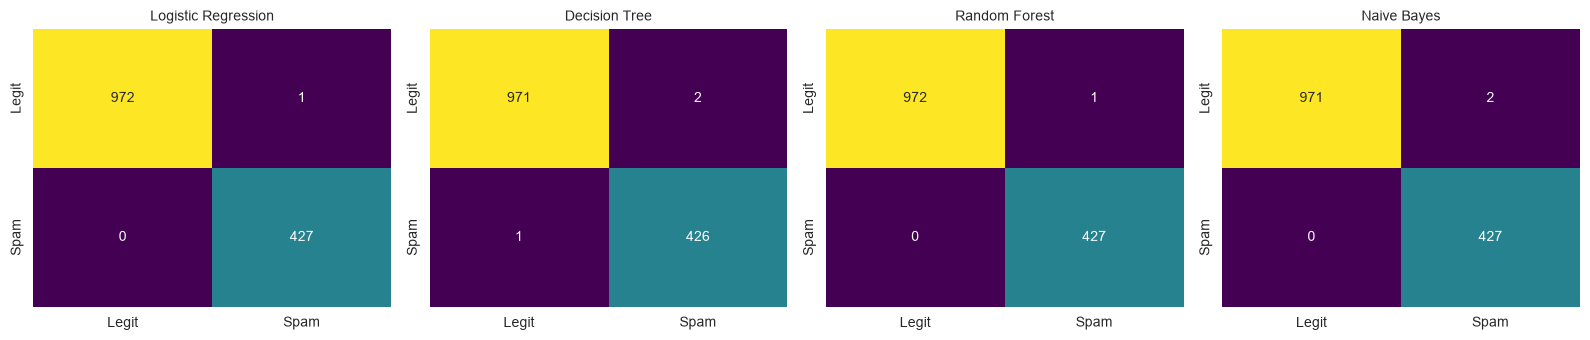

In [37]:
fig, axes = plt.subplots(1, len(candidates), figsize=(16, 3.5))
for ax, name in zip(axes, candidates):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", cbar=False, ax=ax,
                xticklabels=["Legit", "Spam"], yticklabels=["Legit", "Spam"])
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()


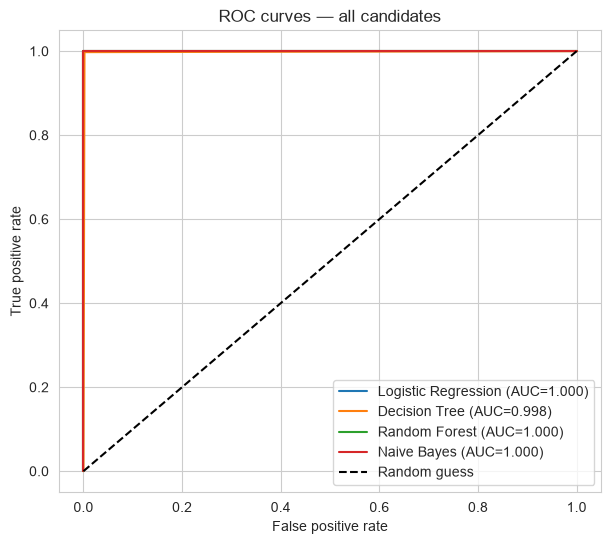

In [38]:
plt.figure(figsize=(7, 6))
for name in candidates:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves — all candidates")
plt.legend()
plt.show()


In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, clf in candidates.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = (scores.mean(), scores.std())
    print(f"{name:20s}  ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")


Logistic Regression   ROC-AUC = 1.0000 ± 0.0000
Decision Tree         ROC-AUC = 0.9986 ± 0.0014
Random Forest         ROC-AUC = 1.0000 ± 0.0000
Naive Bayes           ROC-AUC = 0.9995 ± 0.0009


In [40]:
def counterfactual(pipe, length, links, special, caps, attach=0, subject="Meeting", domain="company.com"):
    row = pd.DataFrame([{
        "Sender_Email": f"user@{domain}", "Subject": subject,
        "Email_Length": length, "Num_Links": links,
        "Num_Special_Chars": special, "Capital_Words": caps,
        "Has_Attachment": attach,
    }])
    feat = add_engineered_columns(row)[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
    return pipe.predict_proba(feat)[0, 1]

print(f"{'Model':22s} {'Long+clean':>12s} {'Short+spammy':>14s}")
for name, pipe in fitted_pipelines.items():
    long_clean = counterfactual(pipe, 262, 0, 0, 0)   # max length, everything else spotless
    short_spam = counterfactual(pipe, 20, 10, 20, 15)  # min length, everything else screaming spam
    print(f"{name:22s} {long_clean*100:11.1f}% {short_spam*100:13.1f}%")


Model                    Long+clean   Short+spammy
Logistic Regression           69.7%          99.6%
Decision Tree                100.0%         100.0%
Random Forest                 46.2%          81.0%
Naive Bayes                  100.0%         100.0%


In [ ]:
raw_best_name = results_df["ROC-AUC"].idxmax()
print("Top model by raw ROC-AUC:", raw_best_name)

best_name = "Random Forest"
best_pipeline = fitted_pipelines[best_name]
print("Deployed model:", best_name, "(chosen for robustness, not just top ROC-AUC)")

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(best_pipeline, MODELS_DIR / "spam_pipeline.joblib")

import json
metrics_out = {
    name.lower().replace(" ", "_"): {
        "accuracy": results[name]["Accuracy"],
        "precision": results[name]["Precision"],
        "recall": results[name]["Recall"],
        "f1": results[name]["F1"],
        "roc_auc": results[name]["ROC-AUC"],
        "confusion_matrix": confusion_matrix(y_test, predictions[name]).tolist(),
        "roc_curve": {
            "fpr": roc_curve(y_test, probabilities[name])[0].tolist(),
            "tpr": roc_curve(y_test, probabilities[name])[1].tolist(),
        },
    }
    for name in candidates
}
metrics_out["best_model"] = best_name.lower().replace(" ", "_")
with open(MODELS_DIR / "metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

clf_final = best_pipeline.named_steps["clf"]
feature_names = best_pipeline.named_steps["prep"].get_feature_names_out()
importances = (
    clf_final.feature_importances_ if hasattr(clf_final, "feature_importances_")
    else np.abs(clf_final.coef_[0]) if hasattr(clf_final, "coef_")
    else np.ones(len(feature_names))
)
fi_sorted = sorted(zip(feature_names, importances.tolist()), key=lambda t: -t[1])
with open(MODELS_DIR / "feature_importance.json", "w") as f:
    json.dump(fi_sorted, f, indent=2)

print("Saved: spam_pipeline.joblib, metrics.json, feature_importance.json")


Top model by raw ROC-AUC: Logistic Regression
Deployed model: Random Forest (chosen for robustness, not just top ROC-AUC)


Saved: spam_pipeline.joblib, metrics.json, feature_importance.json


In [42]:
loaded_pipeline = joblib.load(MODELS_DIR / "spam_pipeline.joblib")

new_emails = pd.DataFrame([
    {
        "Sender_Email": "promo@offers-daily.net", "Subject": "Win Prize",
        "Email_Length": 320, "Num_Links": 6, "Num_Special_Chars": 18,
        "Capital_Words": 12, "Has_Attachment": 0,
    },
    {
        "Sender_Email": "manager@company.com", "Subject": "Project Update",
        "Email_Length": 140, "Num_Links": 0, "Num_Special_Chars": 2,
        "Capital_Words": 1, "Has_Attachment": 1,
    },
])
new_emails_feat = add_engineered_columns(new_emails)[CATEGORICAL_FEATURES + NUMERIC_FEATURES]

preds = loaded_pipeline.predict(new_emails_feat)
probs = loaded_pipeline.predict_proba(new_emails_feat)[:, 1]
for i, (p, prob) in enumerate(zip(preds, probs)):
    verdict = "SPAM" if p == 1 else "LEGITIMATE"
    print(f"Email {i+1}: {verdict}  (spam probability = {prob*100:.1f}%)")


Email 1: SPAM  (spam probability = 100.0%)
Email 2: LEGITIMATE  (spam probability = 5.2%)
